# Tarea 1 – Spark MLlib Classification Pipeline

In this lab you will:
- Build a binary classification dataset
- Create a Spark ML pipeline
- Train a classifier and evaluate accuracy

_Nota (ES): Conectar con problemas de churn, fraude o riesgo de crédito._

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName('MLlibLab').getOrCreate()

In [5]:
import pandas as pd
import numpy as np

n = 5000 # Define n here
# pdf = pd.DataFrame({
#     'feature_1': np.random.randn(n),
#     'feature_2': np.random.randn(n),
#     'feature_3': np.random.randn(n),
#     'label': np.random.choice([0, 1], size=n, p=[0.7, 0.3])
# })
#
# csv_path = 'binary_classification_sample.csv'
# pdf.to_csv(csv_path, index=False)
#
# df = spark.read.csv(csv_path, header=True, inferSchema=True)

pdf_improved = pd.DataFrame({
    'feature_1': np.random.randn(n),
    'feature_2': np.random.randn(n),
    'feature_3': np.random.randn(n)
})
# Create a label that depends on the features, for example:
pdf_improved['label'] = ((pdf_improved['feature_1'] + 2*pdf_improved['feature_2'] - 0.5*pdf_improved['feature_3']) > 0).astype(int)

# You can also add some noise to make it more realistic
noise = np.random.rand(n) < 0.1 # 10% of labels are flipped randomly
pdf_improved.loc[noise, 'label'] = 1 - pdf_improved.loc[noise, 'label']

# Then save this new dataset and use it for training:
csv_path_improved = 'improved_binary_classification_sample.csv'
pdf_improved.to_csv(csv_path_improved, index=False)
df_improved = spark.read.csv(csv_path_improved, header=True, inferSchema=True)

# df.show(5) # This line also refers to a commented out 'df', so it should be commented or removed if df is not intended to be used

## 1. Build a Pipeline

We will assemble features and train a logistic regression model.

In [6]:
feature_cols = ['feature_1', 'feature_2', 'feature_3']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

lr = LogisticRegression(featuresCol='features', labelCol='label')
pipeline = Pipeline(stages=[assembler, lr])

# train, test = df.randomSplit([0.8, 0.2], seed=42)
train_improved, test_improved = df_improved.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train_improved)

predictions = model.transform(test_improved)
predictions.select('features', 'label', 'probability', 'prediction').show(10)

+--------------------+-----+--------------------+----------+
|            features|label|         probability|prediction|
+--------------------+-----+--------------------+----------+
|[-3.4428502068905...|    0|[0.99808692893298...|       0.0|
|[-2.9729055510717...|    0|[0.99430797774216...|       0.0|
|[-2.9135401487332...|    0|[0.89661367117896...|       0.0|
|[-2.7891015020193...|    0|[0.86236864557806...|       0.0|
|[-2.7048692379437...|    1|[0.98524186552224...|       0.0|
|[-2.5701061195810...|    0|[0.93609718642797...|       0.0|
|[-2.4888556548463...|    0|[0.88424793600317...|       0.0|
|[-2.4693498796861...|    0|[0.99384778974217...|       0.0|
|[-2.3266385047908...|    0|[0.98119467748392...|       0.0|
|[-2.3067524564600...|    1|[0.35429939228145...|       1.0|
+--------------------+-----+--------------------+----------+
only showing top 10 rows


In [7]:
from pyspark.ml.classification import LinearSVC

# Create a Linear Support Vector Machine (SVM) model
svm = LinearSVC(featuresCol='features', labelCol='label', maxIter=10)

# Create a new pipeline with the SVM model
pipeline_svm = Pipeline(stages=[assembler, svm])

# Fit the pipeline to the training data
model_svm = pipeline_svm.fit(train_improved)

# Make predictions on the test data
predictions_svm = model_svm.transform(test_improved)
predictions_svm.select('features', 'label', 'rawPrediction', 'prediction').show(10)

+--------------------+-----+--------------------+----------+
|            features|label|       rawPrediction|prediction|
+--------------------+-----+--------------------+----------+
|[-3.4428502068905...|    0|[5.59946512640127...|       0.0|
|[-2.9729055510717...|    0|[4.63011459404823...|       0.0|
|[-2.9135401487332...|    0|[1.93255108671466...|       0.0|
|[-2.7891015020193...|    0|[1.61376442985861...|       0.0|
|[-2.7048692379437...|    1|[3.77104812476904...|       0.0|
|[-2.5701061195810...|    0|[2.40058205515576...|       0.0|
|[-2.4888556548463...|    0|[1.82345631483710...|       0.0|
|[-2.4693498796861...|    0|[4.56369551040205...|       0.0|
|[-2.3266385047908...|    0|[3.52658916457400...|       0.0|
|[-2.3067524564600...|    1|[-0.5386911464278...|       1.0|
+--------------------+-----+--------------------+----------+
only showing top 10 rows


In [8]:
from pyspark.ml.classification import RandomForestClassifier

# Create a Random Forest classifier model
rf = RandomForestClassifier(featuresCol='features', labelCol='label', numTrees=10)

# Create a new pipeline with the Random Forest model
pipeline_rf = Pipeline(stages=[assembler, rf])

# Fit the pipeline to the training data
model_rf = pipeline_rf.fit(train_improved)

# Make predictions on the test data
predictions_rf = model_rf.transform(test_improved)
predictions_rf.select('features', 'label', 'rawPrediction', 'prediction').show(10)

+--------------------+-----+--------------------+----------+
|            features|label|       rawPrediction|prediction|
+--------------------+-----+--------------------+----------+
|[-3.4428502068905...|    0|[8.96932766857148...|       0.0|
|[-2.9729055510717...|    0|[8.96932766857148...|       0.0|
|[-2.9135401487332...|    0|[8.03634446817852...|       0.0|
|[-2.7891015020193...|    0|[5.29531511450709...|       0.0|
|[-2.7048692379437...|    1|[8.85038959189625...|       0.0|
|[-2.5701061195810...|    0|[9.01295816763017...|       0.0|
|[-2.4888556548463...|    0|[8.60602758618339...|       0.0|
|[-2.4693498796861...|    0|[8.96932766857148...|       0.0|
|[-2.3266385047908...|    0|[8.82776545119810...|       0.0|
|[-2.3067524564600...|    1|[2.88076062998835...|       1.0|
+--------------------+-----+--------------------+----------+
only showing top 10 rows


In [9]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluate Logistic Regression model accuracy
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy_lr = evaluator.evaluate(predictions)
print(f"Logistic Regression Model Accuracy: {accuracy_lr:.4f}")

Logistic Regression Model Accuracy: 0.9040


In [10]:
# Evaluate SVM model accuracy
accuracy_svm = evaluator.evaluate(predictions_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

SVM Model Accuracy: 0.9029


In [11]:
# Evaluate Random Forest model accuracy
accuracy_rf = evaluator.evaluate(predictions_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")

Random Forest Model Accuracy: 0.8601


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Helper function to plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {title}')
    plt.show()

# Helper function to plot ROC Curve
def plot_roc_curve(y_true, y_scores, title):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {title}')
    plt.legend(loc='lower right')
    plt.show()


--- Logistic Regression Model ---


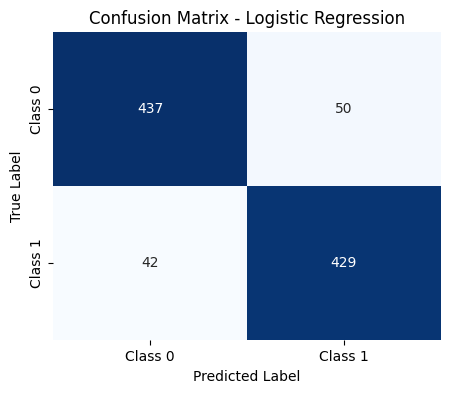

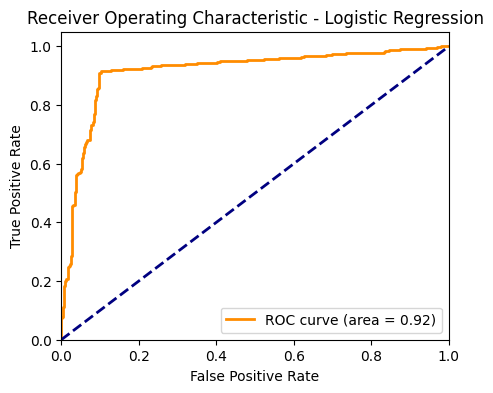

In [20]:
# --- Logistic Regression --- #
print("\n--- Logistic Regression Model ---")
predictions_lr_pd = predictions.select('label', 'prediction', 'probability').toPandas()

# Confusion Matrix
plot_confusion_matrix(predictions_lr_pd['label'], predictions_lr_pd['prediction'], 'Logistic Regression')

# ROC Curve
# 'probability' column is a vector; we need the probability of the positive class (index 1)
prob_lr_positive = predictions_lr_pd['probability'].apply(lambda x: x[1])
plot_roc_curve(predictions_lr_pd['label'], prob_lr_positive, 'Logistic Regression')


--- SVM Model ---


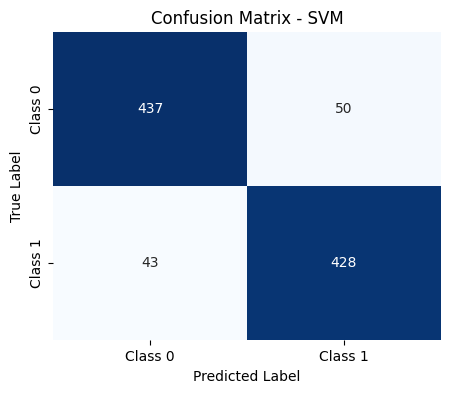

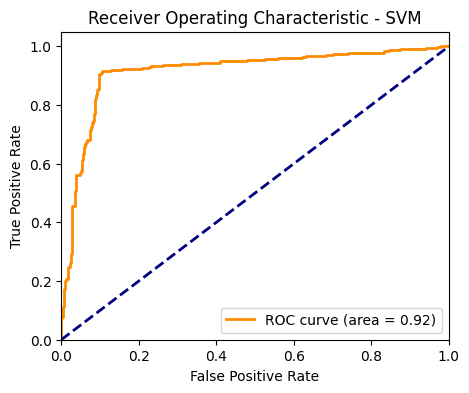

In [21]:
# --- SVM --- #
print("\n--- SVM Model ---")
predictions_svm_pd = predictions_svm.select('label', 'prediction', 'rawPrediction').toPandas()

# Confusion Matrix
plot_confusion_matrix(predictions_svm_pd['label'], predictions_svm_pd['prediction'], 'SVM')

# ROC Curve
# 'rawPrediction' for LinearSVC is a vector of scores. We use the score for the positive class (index 1).
# LinearSVC does not directly provide probabilities; raw prediction scores are used as decision function scores.
score_svm_positive = predictions_svm_pd['rawPrediction'].apply(lambda x: x[1])
plot_roc_curve(predictions_svm_pd['label'], score_svm_positive, 'SVM')


--- Random Forest Model ---


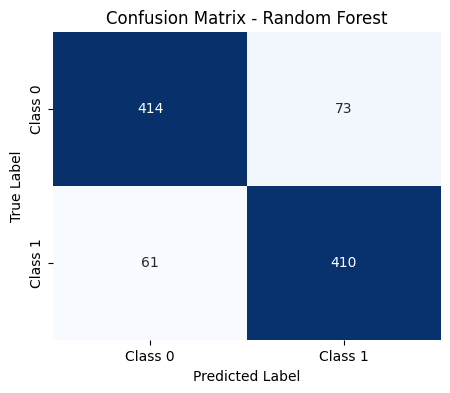

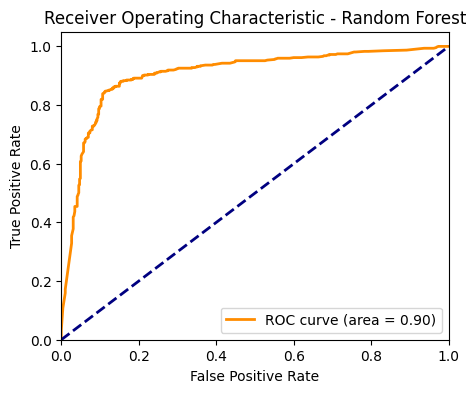

In [22]:
# --- Random Forest --- #
print("\n--- Random Forest Model ---")
predictions_rf_pd = predictions_rf.select('label', 'prediction', 'probability').toPandas()

# Confusion Matrix
plot_confusion_matrix(predictions_rf_pd['label'], predictions_rf_pd['prediction'], 'Random Forest')

# ROC Curve
# 'probability' column is a vector; we need the probability of the positive class (index 1)
prob_rf_positive = predictions_rf_pd['probability'].apply(lambda x: x[1])
plot_roc_curve(predictions_rf_pd['label'], prob_rf_positive, 'Random Forest')

In [23]:
print("\nNote: Generating traditional learning curves (model performance vs. training set size) is computationally intensive in PySpark MLlib as it would require re-fitting the models multiple times with different subsets of the training data. Therefore, they are not included in this output.")


Note: Generating traditional learning curves (model performance vs. training set size) is computationally intensive in PySpark MLlib as it would require re-fitting the models multiple times with different subsets of the training data. Therefore, they are not included in this output.


In [24]:
from pyspark.ml.classification import DecisionTreeClassifier

# Create a Decision Tree Classifier model
dt = DecisionTreeClassifier(featuresCol='features', labelCol='label')

# Create a new pipeline with the Decision Tree model
pipeline_dt = Pipeline(stages=[assembler, dt])

# Fit the pipeline to the training data
model_dt = pipeline_dt.fit(train_improved)

# Make predictions on the test data
predictions_dt = model_dt.transform(test_improved)
predictions_dt.select('features', 'label', 'rawPrediction', 'prediction').show(10)

# Evaluate Decision Tree model accuracy
accuracy_dt = evaluator.evaluate(predictions_dt)
print(f"\nDecision Tree Model Accuracy: {accuracy_dt:.4f}")

+--------------------+-----+--------------+----------+
|            features|label| rawPrediction|prediction|
+--------------------+-----+--------------+----------+
|[-3.4428502068905...|    0|[1288.0,206.0]|       0.0|
|[-2.9729055510717...|    0|[1288.0,206.0]|       0.0|
|[-2.9135401487332...|    0|  [182.0,24.0]|       0.0|
|[-2.7891015020193...|    0|     [6.0,1.0]|       0.0|
|[-2.7048692379437...|    1|[1288.0,206.0]|       0.0|
|[-2.5701061195810...|    0|  [182.0,24.0]|       0.0|
|[-2.4888556548463...|    0|  [182.0,24.0]|       0.0|
|[-2.4693498796861...|    0|[1288.0,206.0]|       0.0|
|[-2.3266385047908...|    0|[1288.0,206.0]|       0.0|
|[-2.3067524564600...|    1|  [33.0,131.0]|       1.0|
+--------------------+-----+--------------+----------+
only showing top 10 rows

Decision Tree Model Accuracy: 0.8476


# Tarea 1

Hacer los sguientes cambios y hacer el análisis respectivo.

In [ ]:

# import numpy as np
# import pandas as pd
#
# n = 5000
# pdf_improved = pd.DataFrame({
#     'feature_1': np.random.randn(n),
#     'feature_2': np.random.randn(n),
#     'feature_3': np.random.randn(n)
# })
# # Create a label that depends on the features, for example:
# pdf_improved['label'] = ((pdf_improved['feature_1'] + 2*pdf_improved['feature_2'] - 0.5*pdf_improved['feature_3']) > 0).astype(int)
# # You can also add some noise to make it more realistic
# noise = np.random.rand(n) < 0.1 # 10% of labels are flipped randomly
# pdf_improved.loc[noise, 'label'] = 1 - pdf_improved.loc[noise, 'label']
#
# # Then save this new dataset and use it for training:
# csv_path_improved = 'improved_binary_classification_sample.csv'
# pdf_improved.to_csv(csv_path_improved, index=False)
# df_improved = spark.read.csv(csv_path_improved, header=True, inferSchema=True)
# train_improved, test_improved = df_improved.randomSplit([0.8, 0.2], seed=42)
#
# # And re-run your pipelines with train_improved and test_improved

**RESPUESTA:**

En la situación inicial, la variable objetivo (label) se generaba de forma aletaria, sin dependencia de las variables predictoras (feature_1, feature_2 y feature_3).

Por este motivo, los modelos de clasificación (regresión logística, SVM y Random Forest) no tenían un patrón claro de aprendizaje.

Con el cambio realizado, la variable objetivo (label) se genera como una combinación matemática de las variables predictoras con la siguiente fórmula:

feature_1 + 2*feature_2 - 0.5*feature_3, clasificando como clase 1 cuando el resultado de la ecuación es mayor a cero, caso contraro, se clasificaca como clase 0.

Adicionalmente, se agregó un 10% de ruido aleatorio, a fin de que el dataset no sea perfecto y se asemeje a un escenario real.

Con estos cambios, al generanse ya una dependencia de la variable objetivo con las variables predictoras, se vuelven a correr los modelos y tener los siguientes resultados:

**ANÁLISIS DE LOS MODELOS CON LA ACTUALIZACIÓN:**

1. Regresión logística obtuvo el mejor resultado con una exactitud de 0.9040. En su matríz de confusión clasificó correctamente 437 casos de clase 0 y 429 casos de clase 1, solo cometió 42 falsos positivos y 50 falsos negativos.
2. Modelo SVM tuvo resultado similar, con una exactitud de 0.9029. En su matríz de confusión clasificó correctamente 437 casos de clase 0 y 428 casos de clase 1. Demuestra buen aprendizaje
3. Modelo Random Forest obtuvo un resultado de exactitud de 0.8601. Aunque su desempeño es bueno, cometío más errores que los dos modelos anteriores (61 falsos positivos y 73 falsos negativos)
4. El modelo árbol de decisión tuvo el menor desempeño con una exactitud de 0.8476.

**Conclusiones respecto a los modelos:**
- En base a estos resultados, el modelo de mayor exactitud es el de regresión logística (exactitud 0.9040)
- Tiene resultados similares al SVM pero ligeramente mayor.
- Los otros dos modelos también tienen buenos resultados, pero su desempeño fue menor
- Regresión logística representa el mejor equilibrio entre precisión, simplicidad e interpretabilidad.